#  Fractals & Strange Attractors

> **Learning goal:** Understand fractal geometry as the *natural language of chaotic attractors* — and why measuring the fractal dimension of a system's phase-space trajectory is the most principled tool we have for quantifying the complexity of a learned representation.

> **Strogatz coverage:** §11.3–11.4 (fractal dimension), §12 (strange attractors). Supplemented by Grassberger & Procaccia (1983).

---

## 1. The "Empty Space" Problem — Why Euclidean Dimensions Fail

Standard geometry assumes space is smooth and uniformly filled. A line has dimension 1, a plane dimension 2, a cube dimension 3. But real attractors, coastlines, and neural activation manifolds are *not* smooth — they have fine structure at arbitrarily small scales.

**The formal definition:** A **fractal** is a set with:
1. A non-integer (Hausdorff) dimension
2. Self-similarity at all scales (exact or statistical)
3. Fine structure that cannot be described by classical geometry

### 1A. The Cantor Set — The Simplest Fractal

Construction: Take $[0,1]$, remove the open middle third. Repeat on each remaining segment forever.

After $n$ iterations:
- Total length: $\left(\frac{2}{3}\right)^n \to 0$ as $n \to \infty$
- Number of segments: $2^n$
- Number of points remaining: **uncountably infinite** (all limit points of the construction)

**Dimension:**

$$d_{\text{box}} = \frac{\ln 2}{\ln 3} \approx 0.631$$

The Cantor set is *too big to be 0-dimensional* (uncountably many points) yet *too small to be 1-dimensional* (zero length). It lives between.

### 1B. The Manifold Hypothesis — The Correct AI Framing

The right framing for AI is not "the latent space is a Cantor set" — it is the **Manifold Hypothesis**:

> High-dimensional data (images, text tokens, hidden states) does not fill its ambient space uniformly. Instead it concentrates near a **low-dimensional manifold** embedded in that high-dimensional space.

Empirical evidence:
- ImageNet images live in $\mathbb{R}^{150000}$ (pixel space) but their intrinsic dimension is roughly 40–50 (Pope et al., ICLR 2021)
- Hidden states in CNNs show a "hunchback" intrinsic dimension curve: rising through early layers, then collapsing at the final layer — this collapse enables classification (Ansuini et al., NeurIPS 2019)
- Deep networks converge faster when the training data manifold has lower intrinsic dimension

**Fractal geometry enters here:** The manifold is not always smooth. Strange attractors — which model chaotic hidden-state dynamics — have *fractal* structure. The Lorenz attractor has $d_{\text{corr}} \approx 2.06$: not a surface ($d=2$) nor a volume ($d=3$). Measuring this dimension tells you whether a model's internal state is:

| $d_{\text{corr}}$ range | Interpretation |
|---|---|
| Near 0 | Collapsed to fixed point — no dynamics |
| Integer $1, 2, \ldots$ | Periodic or quasi-periodic — regular |
| Non-integer, low | Strange attractor — structured chaos |
| Grows with embedding dim | Stochastic — no underlying structure |

---

## 2. Measuring Complexity — Three Fractal Dimensions

### 2A. Hausdorff Dimension

The mathematically rigorous definition. Cover the set with balls of radius $\epsilon$; the Hausdorff dimension is the critical exponent where the measure transitions from $\infty$ to $0$. Used for proofs, not numerical algorithms.

### 2B. Box-Counting Dimension

Cover the set with a grid of boxes of side $\epsilon$, count $N(\epsilon)$ occupied boxes:

$$d_{\text{box}} = \lim_{\epsilon \to 0} \frac{\ln N(\epsilon)}{\ln(1/\epsilon)}$$

The slope of the log-log plot of $N(\epsilon)$ vs $1/\epsilon$ gives $d_{\text{box}}$.

**Computational limit:** For an ambient space of dimension $D$, you need $\epsilon^{-D}$ boxes. For a 4096-dimensional embedding, this is astronomically infeasible.

### 2C. Correlation Dimension — Grassberger & Procaccia (1983)

The computationally tractable alternative. Sample $n$ points on the attractor. Define the **correlation integral**:

$$C(\epsilon) = \lim_{n \to \infty} \frac{2}{n(n-1)} \sum_{i < j} \mathbf{1}\bigl[\|x_i - x_j\| < \epsilon\bigr]$$

This is the fraction of point pairs closer than $\epsilon$. In the **geometric scaling region**:

$$C(\epsilon) \propto \epsilon^{d_{\text{corr}}}$$

$$\boxed{d_{\text{corr}} = \lim_{\epsilon \to 0} \frac{\ln C(\epsilon)}{\ln \epsilon}}$$

Computed as the **slope of the log-log plot** of $C(\epsilon)$ vs $\epsilon$ — but **only in the scaling region** where $0 < C(\epsilon) < 1$:
- $C \approx 0$: below the noise floor, too few pairs — not yet geometric
- $C \approx 1$: saturated, all pairs inside — no geometric information

**Crucial test (Scholarpedia):**
- **Stochastic signal:** $C(\epsilon, m) \sim \epsilon^m$ — apparent dimension grows with embedding $m$, never saturates
- **Deterministic chaos:** $C(\epsilon, m) \sim \epsilon^{D}$ — saturates at the true attractor dimension $D$ as $m$ increases

This is how you formally distinguish *structured complexity* from *noise*.

**Known values:**

| System | $d_{\text{corr}}$ |
|---|---|
| Fixed point | 0 |
| Limit cycle | 1 |
| 2-torus | 2 |
| Lorenz attractor | ≈ 2.06 |
| Rössler attractor | ≈ 2.01 |
| White noise | → ∞ |

---

## 3. Multifractals — Non-Uniform Scaling

Real attractors and real datasets are not uniformly dense. Some regions are visited frequently, others rarely. A **multifractal** requires a *spectrum* of dimensions rather than a single number.

### The Rényi (Generalised) Dimensions $D_q$

Partition the attractor into boxes of size $\epsilon$, let $\mu_i$ be the natural measure (visitation probability) of box $i$:

$$D_q = \lim_{\epsilon \to 0} \frac{1}{1-q} \frac{\ln \sum_i \mu_i^q}{\ln \epsilon}$$

The index $q$ acts as a "magnifying glass":
- $q < 0$: emphasises *sparse* regions
- $q = 0$: $D_0$ = box dimension (counts occupied boxes, ignoring $\mu$)
- $q = 1$: $D_1$ = information dimension (Shannon entropy of the measure)
- $q = 2$: $D_2$ = correlation dimension (what G-P computes)
- $q > 2$: emphasises *dense* regions

**For a monofractal:** $D_q$ is flat — density is uniform everywhere.  
**For a multifractal:** $D_q$ decreases monotonically in $q$ — the system has a heterogeneous density.

### The Singularity Spectrum $f(\alpha)$

For each point $x$, the local pointwise dimension $\alpha(x)$ satisfies $\mu(B_\epsilon(x)) \sim \epsilon^{\alpha(x)}$. The set of points sharing the same $\alpha$ forms a sub-fractal of dimension $f(\alpha)$.

**Properties:**
- $f(\alpha)$ is a concave function (inverted-parabola shape)
- $\max_\alpha f(\alpha) = D_0$ — the box dimension
- Width of $f(\alpha)$: narrow = near-uniform (monofractal); wide = highly heterogeneous (multifractal)

**AI link:** Token frequency in natural language follows Zipf's law — a power law. This is a signature of multifractal structure: common concepts (dense regions) and rare concepts (sparse regions) coexist at all scales. An LLM's hidden-state distribution inherits this heterogeneity.

---

## 4. The Lorenz Strange Attractor

The canonical strange attractor (Lorenz, 1963):

$$\dot{x} = \sigma(y - x) \qquad \dot{y} = x(\rho - z) - y \qquad \dot{z} = xy - \beta z$$

Standard parameters: $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.

**Why it is "strange":**

| Property | Value |
|---|---|
| Bounded? | Yes — never escapes to infinity |
| Periodic? | No — never exactly repeats |
| Sensitive to ICs? | Yes — nearby trajectories diverge exponentially (Lyapunov $\lambda \approx 0.9$) |
| Fractal dimension | $d_{\text{corr}} \approx 2.06$ |

Its dimension $\approx 2.06$ means it is a surface folded infinitely — too complex to be a smooth 2D manifold, not dense enough to be a 3D volume. Its Poincaré section reveals a fractal cross-section, not a simple curve.

---

## 5. Code: Five Visualisations

### 5A. Cantor Set Construction + Box Dimension Verification


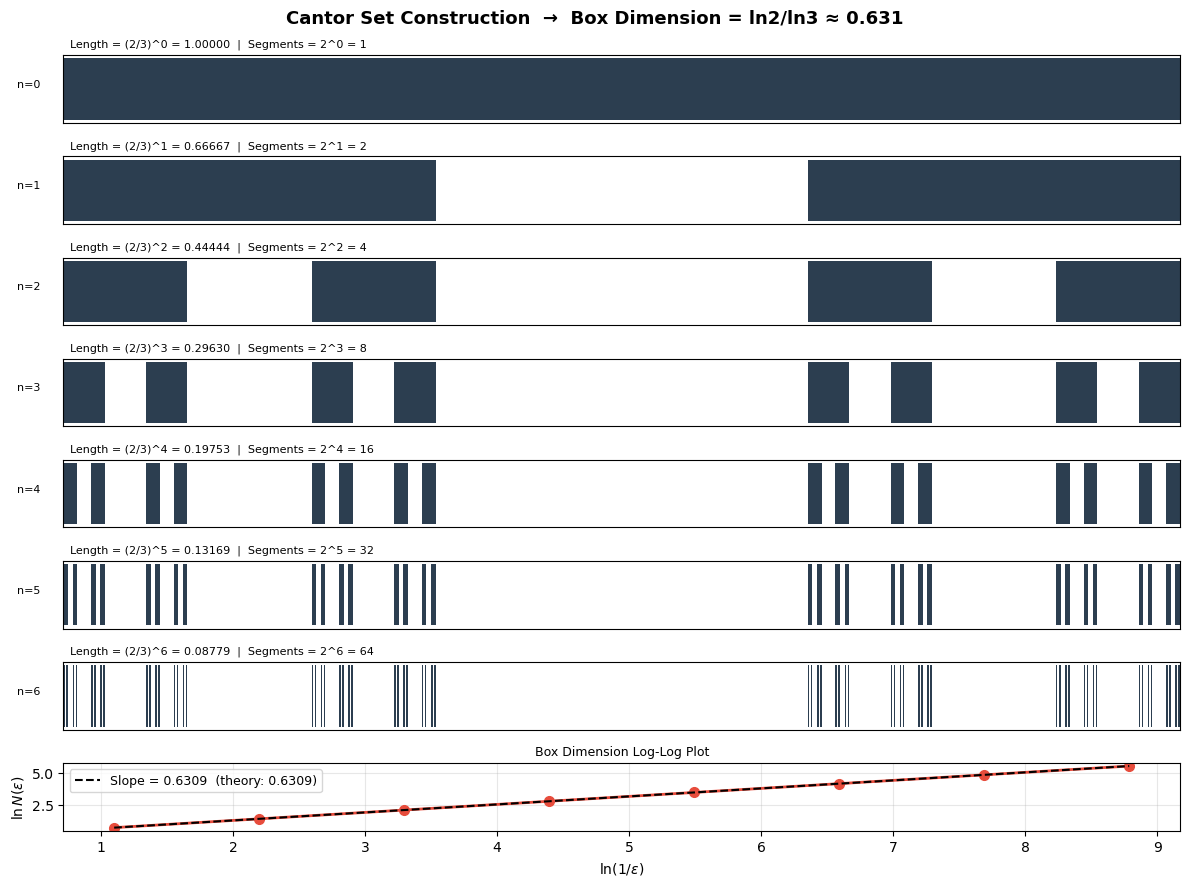

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def cantor_segments(n_iterations):
    """Returns list of (start, end) segments after n Cantor iterations."""
    segments = [(0.0, 1.0)]
    for _ in range(n_iterations):
        new_segs = []
        for (a, b) in segments:
            t = (b - a) / 3
            new_segs.append((a, a + t))
            new_segs.append((b - t, b))
        segments = new_segs
    return segments

def box_dimension_cantor(max_iter=8):
    """
    Numerically verify d_box = log(2)/log(3).
    At iteration n: N = 2^n boxes, each of size eps = (1/3)^n.
    """
    ns          = np.arange(1, max_iter + 1)
    N_boxes     = 2.0 ** ns
    eps         = (1/3.0) ** ns
    log_N       = np.log(N_boxes)
    log_inv_eps = np.log(1.0 / eps)
    slope, _    = np.polyfit(log_inv_eps, log_N, 1)
    return slope, log_inv_eps, log_N

n_rows = 7
fig, axes = plt.subplots(n_rows + 1, 1, figsize=(12, 9))
fig.suptitle("Cantor Set Construction  →  Box Dimension = ln2/ln3 ≈ 0.631",
             fontsize=13, fontweight="bold")

for i in range(n_rows):
    segs  = cantor_segments(i)
    ax    = axes[i]
    total = sum(b - a for a, b in segs)
    for (a, b) in segs:
        ax.barh(0, b - a, left=a, height=0.6, color="#2C3E50")
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
    ax.set_ylabel(f"n={i}", fontsize=8, rotation=0, labelpad=25)
    ax.set_title(
        f"  Length = (2/3)^{i} = {total:.5f}  |  Segments = 2^{i} = {2**i}",
        fontsize=8, loc="left")

slope, log_inv_eps, log_N = box_dimension_cantor()
ax_d = axes[-1]
ax_d.plot(log_inv_eps, log_N, "o-", color="#E74C3C", lw=2, ms=7)
interc = log_N[0] - slope * log_inv_eps[0]
ax_d.plot(log_inv_eps, slope * log_inv_eps + interc, "k--", lw=1.5,
          label=f"Slope = {slope:.4f}  (theory: {np.log(2)/np.log(3):.4f})")
ax_d.set_xlabel("$\\ln(1/\\epsilon)$"); ax_d.set_ylabel("$\\ln N(\\epsilon)$")
ax_d.set_title("Box Dimension Log-Log Plot", fontsize=9)
ax_d.legend(fontsize=9); ax_d.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("5A_cantor_set.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 5B. Hopf Bifurcation — Corrected Streamplot

> **Bug fixed:** `streamplot` requires a uniform Cartesian grid. The original code built a polar meshgrid then converted — giving non-uniform $(x,y)$ spacing and garbled arrows. **Fix:** meshgrid directly in $(x,y)$, compute $(r,\theta)$ per point to evaluate the polar normal form.


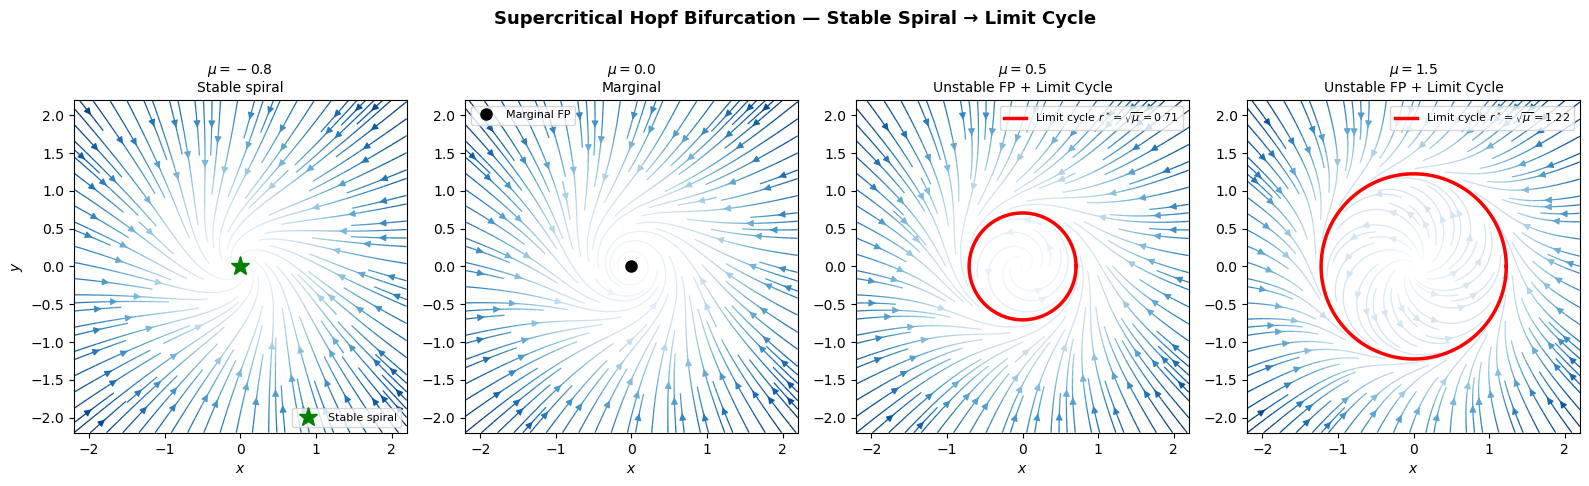

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def hopf_cartesian(x, y, mu, omega=1.0, b=0.0):
    """
    Supercritical Hopf normal form evaluated on a Cartesian grid.
    Polar form:  dr/dt = mu*r - r^3,   dtheta/dt = omega + b*r^2
    """
    r2 = x**2 + y**2
    r  = np.sqrt(r2) + 1e-10          # avoid division by zero
    drdt     = mu * r - r**3
    dthetadt = omega + b * r2
    cos_t = x / r;  sin_t = y / r
    dxdt  = drdt * cos_t - r * dthetadt * sin_t
    dydt  = drdt * sin_t + r * dthetadt * cos_t
    return dxdt, dydt

mu_values = [-0.8, 0.0, 0.5, 1.5]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Supercritical Hopf Bifurcation — Stable Spiral → Limit Cycle",
             fontsize=13, fontweight="bold")

# ── Uniform Cartesian grid — correct for streamplot ───────────────────────────
xg = np.linspace(-2.2, 2.2, 30)
yg = np.linspace(-2.2, 2.2, 30)
X, Y = np.meshgrid(xg, yg)

for ax, mu in zip(axes, mu_values):
    DX, DY = hopf_cartesian(X, Y, mu)
    speed  = np.sqrt(DX**2 + DY**2) + 1e-8
    ax.streamplot(X, Y, DX, DY, color=np.log1p(speed),
                  cmap="Blues", density=1.4, linewidth=0.9, arrowsize=1.0)

    if mu > 0:
        r_lc = np.sqrt(mu)
        theta = np.linspace(0, 2*np.pi, 300)
        ax.plot(r_lc*np.cos(theta), r_lc*np.sin(theta),
                "r-", lw=2.5,
                label=f"Limit cycle $r^*=\\sqrt{{\\mu}}={r_lc:.2f}$")
        ax.legend(fontsize=8, loc="upper right")
    elif mu == 0:
        ax.plot(0, 0, "ko", ms=8, label="Marginal FP")
        ax.legend(fontsize=8)
    else:
        ax.plot(0, 0, "g*", ms=14, label="Stable spiral")
        ax.legend(fontsize=8)

    label = ("Stable spiral" if mu < 0 else
             "Marginal" if mu == 0 else "Unstable FP + Limit Cycle")
    ax.set_title(f"$\\mu = {mu}$\n{label}", fontsize=10)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
    ax.set_xlabel("$x$")
    if ax is axes[0]: ax.set_ylabel("$y$")

plt.tight_layout()
plt.savefig("5B_hopf_bifurcation.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 5C. Lorenz Strange Attractor + Sensitive Dependence


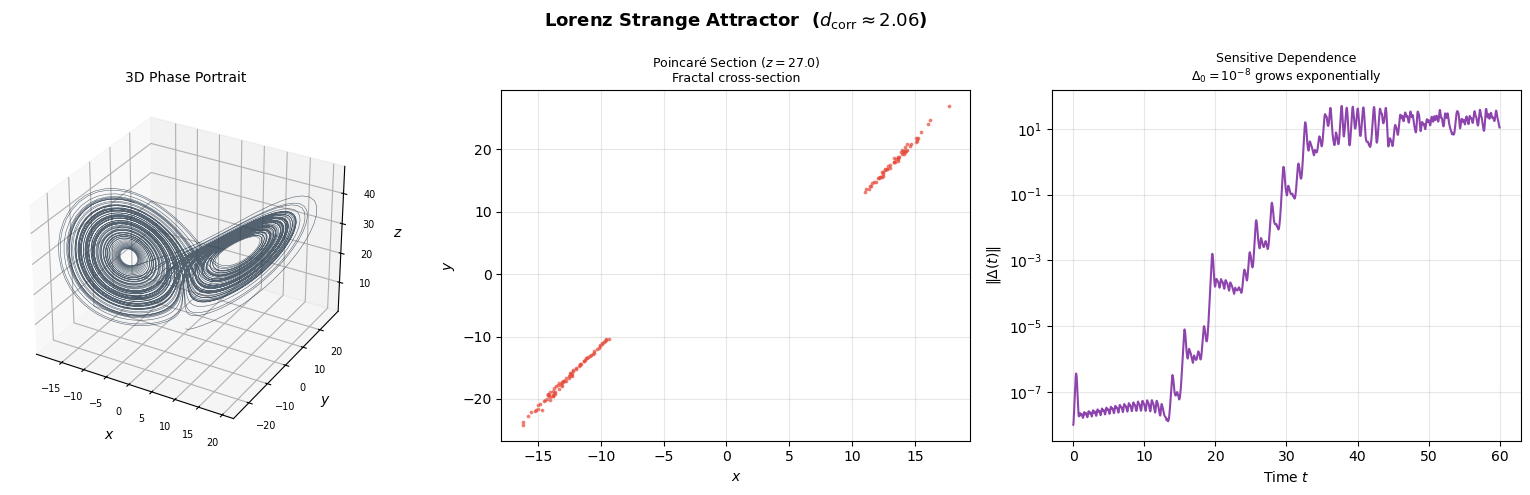

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def lorenz(s, sig=10.0, rho=28.0, bet=8/3):
    return np.array([sig*(s[1]-s[0]), s[0]*(rho-s[2])-s[1], s[0]*s[1]-bet*s[2]])

def rk4(f, s0, dt, n):
    traj = np.empty((n+1, len(s0))); traj[0] = s0
    for i in range(n):
        k1 = f(traj[i]); k2 = f(traj[i]+0.5*dt*k1)
        k3 = f(traj[i]+0.5*dt*k2); k4 = f(traj[i]+dt*k3)
        traj[i+1] = traj[i] + (dt/6)*(k1+2*k2+2*k3+k4)
    return traj

dt = 0.01; N = 10000
s1 = rk4(lorenz, [0.0, 1.0,  1.05],     dt, N)
s2 = rk4(lorenz, [0.0, 1.0+1e-8, 1.05], dt, N)   # tiny IC perturbation

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Lorenz Strange Attractor  ($d_{\\mathrm{corr}} \\approx 2.06$)",
             fontsize=13, fontweight="bold")

# 3D attractor
ax1 = fig.add_subplot(131, projection="3d")
ax1.plot(s1[:,0], s1[:,1], s1[:,2], lw=0.4, color="#2C3E50", alpha=0.8)
ax1.set_title("3D Phase Portrait", fontsize=10)
ax1.set_xlabel("$x$"); ax1.set_ylabel("$y$"); ax1.set_zlabel("$z$")
ax1.tick_params(labelsize=7)

# Poincaré section (upward crossings of z = 27)
ax2 = fig.add_subplot(132)
z0 = 27.0
cx, cy = [], []
for i in range(1, len(s1)):
    if s1[i-1,2] < z0 <= s1[i,2]:
        cx.append(s1[i,0]); cy.append(s1[i,1])
ax2.scatter(cx, cy, s=3, color="#E74C3C", alpha=0.6)
ax2.set_title(f"Poincaré Section ($z={z0}$)\nFractal cross-section", fontsize=9)
ax2.set_xlabel("$x$"); ax2.set_ylabel("$y$"); ax2.grid(True, alpha=0.3)

# Sensitive dependence
ax3 = fig.add_subplot(133)
t_ax = np.arange(N+1)*dt
div  = np.linalg.norm(s1-s2, axis=1)
ax3.semilogy(t_ax[:6000], div[:6000], color="#8E44AD", lw=1.5)
ax3.set_title("Sensitive Dependence\n$\\Delta_0=10^{-8}$ grows exponentially", fontsize=9)
ax3.set_xlabel("Time $t$"); ax3.set_ylabel("$\\|\\Delta(t)\\|$")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("5C_lorenz_attractor.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 5D. Grassberger–Procaccia Correlation Dimension

> **Two bugs fixed from original:**
> 1. `latent_space.shape[5]` → `IndexError` — index out of range. Fixed to `latent_space.shape[1]`.
> 2. Fitting `log(C)` including $C = 0$ (undefined) or $C \approx 1$ (saturated) gives a meaningless slope. Fixed by restricting the fit to the **scaling region** $0 < C(\epsilon) < 0.98$.


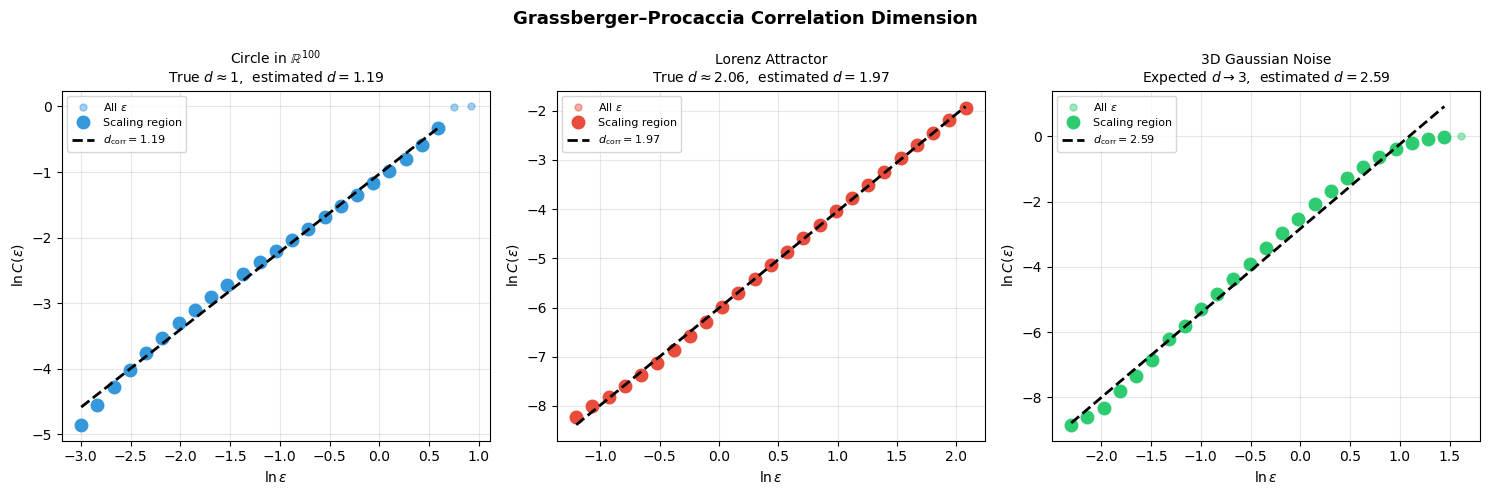


Circle in R^100   -> d_corr = 1.19  (true ~ 1)
Lorenz attractor  -> d_corr = 1.97  (literature: 2.06)
3D Gaussian noise -> d_corr = 2.59  (expected ~ 3)

Key takeaway: the ambient dimension (100) is invisible — only the
intrinsic manifold dimension is measured.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

def correlation_dimension(points, epsilons):
    """
    Grassberger-Procaccia algorithm for correlation dimension.

    Parameters
    ----------
    points   : (n_points, n_dims) — attractor points or hidden states
    epsilons : 1-D array of radii

    Returns
    -------
    d_corr   : estimated correlation dimension
    log_eps  : log(epsilon) for all radii
    log_C    : log(C(epsilon)) for all radii (clipped for display)
    mask     : boolean array marking the scaling region
    """
    dists       = pdist(points, metric="euclidean")
    total_pairs = len(dists)
    C_vals      = np.array([np.sum(dists < eps) / total_pairs for eps in epsilons])

    # Scaling region: strictly 0 < C < 1
    mask = (C_vals > 0.0) & (C_vals < 0.98)
    if mask.sum() < 3:
        raise ValueError(
            "Fewer than 3 points in the scaling region. "
            "Adjust the epsilon range or increase n_points.")

    d_corr, _ = np.polyfit(np.log(epsilons[mask]), np.log(C_vals[mask]), 1)
    return d_corr, np.log(epsilons), np.log(np.clip(C_vals, 1e-12, 1)), mask


np.random.seed(42)

# ── Experiment 1: 1D circle embedded in R^100 ────────────────────────────────
n   = 800
ang = np.linspace(0, 2*np.pi, n)
x   = np.cos(ang) + np.random.normal(0, 0.04, n)
y   = np.sin(ang) + np.random.normal(0, 0.04, n)
latent = np.zeros((n, 100))
latent[:, 0] = x;  latent[:, 1] = y

eps1 = np.geomspace(0.05, 2.5, 25)
d1, le1, lC1, m1 = correlation_dimension(latent, eps1)

# ── Experiment 2: Lorenz attractor (known d ≈ 2.06) ──────────────────────────
def lorenz(s, sig=10, rho=28, bet=8/3):
    return np.array([sig*(s[1]-s[0]), s[0]*(rho-s[2])-s[1], s[0]*s[1]-bet*s[2]])

dt = 0.02; N2 = 6000
traj = np.empty((N2+1,3)); traj[0] = [0.,1.,1.05]
for i in range(N2):
    k1=lorenz(traj[i]); k2=lorenz(traj[i]+0.5*dt*k1)
    k3=lorenz(traj[i]+0.5*dt*k2); k4=lorenz(traj[i]+dt*k3)
    traj[i+1]=traj[i]+(dt/6)*(k1+2*k2+2*k3+k4)
lorenz_pts = traj[1000:]

eps2 = np.geomspace(0.3, 8.0, 25)
d2, le2, lC2, m2 = correlation_dimension(lorenz_pts, eps2)

# ── Experiment 3: Gaussian noise (d → ambient dimension) ─────────────────────
noise = np.random.randn(500, 3)
eps3  = np.geomspace(0.1, 5.0, 25)
d3, le3, lC3, m3 = correlation_dimension(noise, eps3)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Grassberger–Procaccia Correlation Dimension",
             fontsize=13, fontweight="bold")

datasets = [
    (le1, lC1, m1, d1,
     f"Circle in $\\mathbb{{R}}^{{100}}$\nTrue $d\\approx1$,  estimated $d={d1:.2f}$",
     "#3498DB"),
    (le2, lC2, m2, d2,
     f"Lorenz Attractor\nTrue $d\\approx2.06$,  estimated $d={d2:.2f}$",
     "#E74C3C"),
    (le3, lC3, m3, d3,
     f"3D Gaussian Noise\nExpected $d\\to3$,  estimated $d={d3:.2f}$",
     "#2ECC71"),
]

for ax, (le, lC, mask, d, title, c) in zip(axes, datasets):
    ax.plot(le, lC, "o", color=c, ms=5, alpha=0.45, label="All $\\epsilon$")
    ax.plot(le[mask], lC[mask], "o", color=c, ms=9, label="Scaling region")
    xf = np.array([le[mask].min(), le[mask].max()])
    ic = lC[mask].mean() - d * le[mask].mean()
    ax.plot(xf, d*xf + ic, "k--", lw=2.0,
            label=f"$d_{{\\mathrm{{corr}}}} = {d:.2f}$")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$\\ln \\epsilon$"); ax.set_ylabel("$\\ln C(\\epsilon)$")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("5D_correlation_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCircle in R^100   -> d_corr = {d1:.2f}  (true ~ 1)")
print(f"Lorenz attractor  -> d_corr = {d2:.2f}  (literature: 2.06)")
print(f"3D Gaussian noise -> d_corr = {d3:.2f}  (expected ~ 3)")
print("\nKey takeaway: the ambient dimension (100) is invisible — only the")
print("intrinsic manifold dimension is measured.")


---

### 5E. Rényi Generalised Dimensions — Multifractal Spectrum


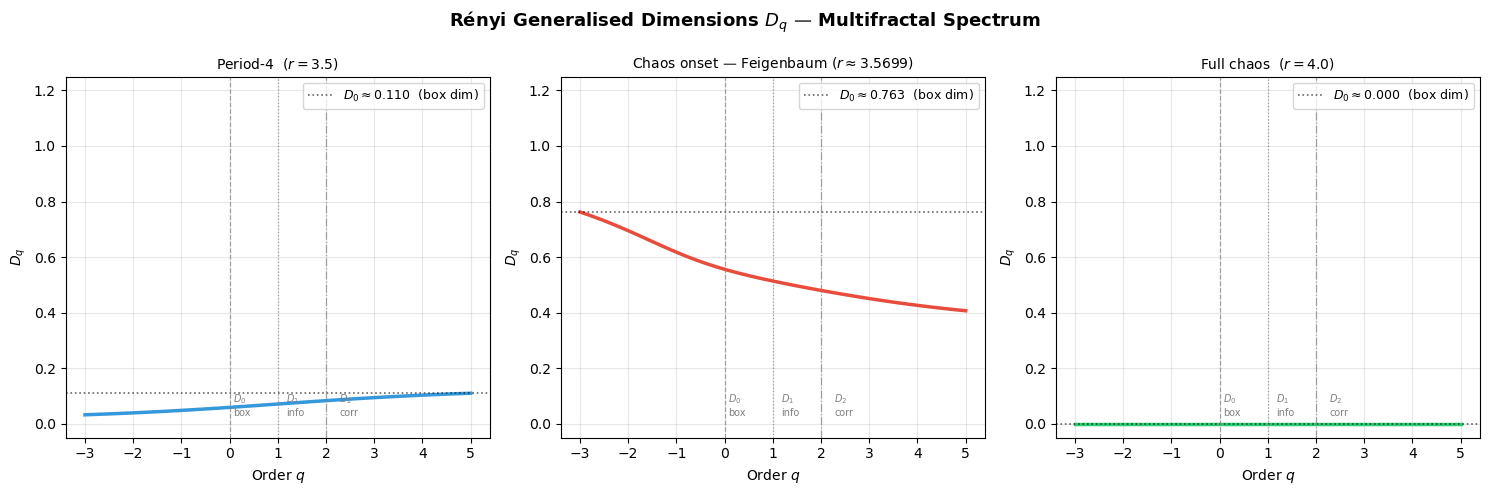

Interpreting the D_q curve:
  Flat (D_q constant in q) -> monofractal: uniform density
  Sloped (D_q decreasing in q) -> multifractal: heterogeneous density
  Width of curve = degree of multifractality
  At Feigenbaum point: D_q < 1 (fractal, not smooth) and sloped (multifractal)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def logistic(r, n_transient=2000, n_keep=8000, x0=0.5):
    x = x0
    for _ in range(n_transient):
        x = r * x * (1 - x)
    pts = []
    for _ in range(n_keep):
        x = r * x * (1 - x)
        pts.append(x)
    return np.array(pts)

def renyi_dims(pts, q_values, epsilons):
    """
    Estimate D_q via box counting on [0,1] for the 1D logistic map.
    D_0: box dim  |  D_1: information dim  |  D_2: correlation dim
    """
    pts = np.clip(pts, 0, 1)
    D_q = []
    for q in q_values:
        log_I_vals = []
        for eps in epsilons:
            n_bins = max(int(1.0/eps), 2)
            counts, _ = np.histogram(pts, bins=n_bins, range=(0.0,1.0))
            probs = counts[counts > 0] / len(pts)
            if q == 1:
                val = -np.sum(probs * np.log(probs + 1e-15))
            else:
                val = np.log(np.sum(probs**q) + 1e-15) / (1 - q)
            log_I_vals.append(val)
        log_inv_eps = np.log(1.0 / epsilons)
        finite = np.isfinite(log_I_vals)
        if finite.sum() > 2:
            slope, _ = np.polyfit(log_inv_eps[finite],
                                   np.array(log_I_vals)[finite], 1)
            D_q.append(slope)
        else:
            D_q.append(np.nan)
    return np.array(D_q)

epsilons = np.geomspace(0.005, 0.15, 15)
q_values = np.linspace(-3, 5, 35)

r_configs = [
    (3.5,      "#3498DB", "Period-4  ($r=3.5$)"),
    (3.5699456,"#E74C3C", "Chaos onset — Feigenbaum ($r \\approx 3.5699$)"),
    (4.0,      "#2ECC71", "Full chaos  ($r=4.0$)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Rényi Generalised Dimensions $D_q$ — Multifractal Spectrum",
             fontsize=13, fontweight="bold")

for ax, (r, c, lbl) in zip(axes, r_configs):
    pts = logistic(r)
    Dq  = renyi_dims(pts, q_values, epsilons)
    finite = np.isfinite(Dq)

    ax.plot(q_values[finite], Dq[finite], color=c, lw=2.5)
    d0 = Dq[finite].max()
    ax.axhline(d0, color="black", ls=":", lw=1.2, alpha=0.6,
               label=f"$D_0 \\approx {d0:.3f}$  (box dim)")

    for qv, ls, lbl2 in [(0,"--","$D_0$"),(1,":","$D_1$"),(2,"-.","$D_2$")]:
        ax.axvline(qv, color="gray", ls=ls, lw=0.9, alpha=0.7)

    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("Order $q$"); ax.set_ylabel("$D_q$")
    ax.set_ylim(-0.05, 1.25)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    note_y = 0.06
    for qv, txt in [(0,"$D_0$\nbox"),(1,"$D_1$\ninfo"),(2,"$D_2$\ncorr")]:
        frac = (qv - q_values.min()) / (q_values.max() - q_values.min())
        ax.text(frac + 0.02, note_y, txt, transform=ax.transAxes,
                fontsize=7, color="gray", ha="left")

plt.tight_layout()
plt.savefig("5E_renyi_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Interpreting the D_q curve:")
print("  Flat (D_q constant in q) -> monofractal: uniform density")
print("  Sloped (D_q decreasing in q) -> multifractal: heterogeneous density")
print("  Width of curve = degree of multifractality")
print("  At Feigenbaum point: D_q < 1 (fractal, not smooth) and sloped (multifractal)")
